#### **The notebooks should be executed in order. Alternatively the notebooks 01 - 04 can be skipped because the data from the API requests is also provided in the csv files in the folder "data".**

# Do iPhone Models with More News Attention Have Worse Amazon Rating Scores?

This notebook tells a simple data story with three sources:

- Amazon Electronics listings provide product titles, star ratings, review counts, and prices.
- GDELT provides a 2023 news-attention signal for each iPhone model.
- Wikipedia provides model release years, which help separate newer launch-cycle phones from older long-tail phones.

Research question: Do iPhone models with more news attention have worse Amazon rating scores?

This analysis uses the average Amazon rating directly from the cleaned data. No extra rating score is calculated. Review counts are still shown as context, but they do not change the rating value.

GDELT mentions are treated as media attention, not as a direct measure of product quality.

## Import Libraries

In [1]:
import math
import os
import re
import sys

spark_home = os.environ.get("SPARK_HOME", "/usr/local/spark")
spark_python_path = os.path.join(spark_home, "python")
py4j_zip_path = os.path.join(spark_python_path, "lib", "py4j-0.10.9.7-src.zip")

for path in [spark_python_path, py4j_zip_path]:
    if os.path.exists(path) and path not in sys.path:
        sys.path.insert(0, path)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    DoubleType,
    IntegerType,
    StringType,
    StructField,
    StructType,
)

## Spark Context and Session

In [2]:
spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("iphone-amazon-rating-news-attention")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

sc = spark.sparkContext
sc.setLogLevel("ERROR")

print(sc.version)
print(sc.master)

3.5.0
local[*]


## Chart Style

In [3]:
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "axes.titlesize": 15,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 120,
})

def add_bar_labels(ax, fmt="{:.2f}", padding=3):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=padding, fontsize=8)

## Load Input Data with PySpark

In [4]:
cleaned_data_file = "data/cleaned-amazon-electronics-sales-2023.csv"
gdelt_file = "data/gdelt-iphone-news-mentions-2023.csv"
wiki_file = "data/wikipedia-iphone-models.csv"

for required_file in [cleaned_data_file, gdelt_file, wiki_file]:
    if not os.path.exists(required_file):
        raise FileNotFoundError(f"{required_file} was not found.")

cleaned_schema = StructType([
    StructField("name", StringType(), True),
    StructField("main_category", StringType(), True),
    StructField("sub_category", StringType(), True),
    StructField("image", StringType(), True),
    StructField("link", StringType(), True),
    StructField("ratings", DoubleType(), True),
    StructField("no_of_ratings", IntegerType(), True),
    StructField("discount_price", DoubleType(), True),
    StructField("actual_price", DoubleType(), True),
])

gdelt_schema = StructType([
    StructField("model_name", StringType(), True),
    StructField("gdelt_mentions_2023", DoubleType(), True),
    StructField("gdelt_query_url", StringType(), True),
    StructField("gdelt_fetch_status", StringType(), True),
])

wiki_schema = StructType([
    StructField("model_name", StringType(), True),
    StructField("initial_os", StringType(), True),
    StructField("release_date", StringType(), True),
    StructField("discontinued_date", StringType(), True),
    StructField("support_ended", StringType(), True),
    StructField("final_os", StringType(), True),
    StructField("support_lifespan_max", StringType(), True),
    StructField("support_lifespan_min", StringType(), True),
    StructField("support_status", StringType(), True),
    StructField("release_year", IntegerType(), True),
])

amazon_df = spark.read.option("header", "true").schema(cleaned_schema).csv(cleaned_data_file)
gdelt_df = spark.read.option("header", "true").schema(gdelt_schema).csv(gdelt_file)
wiki_df = spark.read.option("header", "true").schema(wiki_schema).csv(wiki_file)

print("Amazon rows:", amazon_df.count())
print("GDELT rows:", gdelt_df.count())
print("Wikipedia rows:", wiki_df.count())

Amazon rows: 9411
GDELT rows: 6
Wikipedia rows: 52


## Extract Real iPhone Handset Listings

The Amazon Electronics file contains many accessories. The extraction below keeps titles that look like actual iPhone handsets and rejects obvious cases such as cases, covers, cables, chargers, protectors, adapters, and renewed-store accessories.

In [5]:
wiki_models = (
    wiki_df
    .select("model_name", "release_year", "release_date", "support_status")
    .where(F.col("model_name").rlike("^iPhone"))
    .where(F.col("model_name") != "iPhone")
    .toPandas()
    .sort_values(["release_year", "model_name"], ascending=[False, False])
)

model_names = wiki_models["model_name"].tolist()
model_names[:10]

['iPhone 17e',
 'iPhone Air',
 'iPhone 17 Pro Max',
 'iPhone 17 Pro',
 'iPhone 17',
 'iPhone 16e',
 'iPhone 16 Pro Max',
 'iPhone 16 Pro',
 'iPhone 16 Plus',
 'iPhone 16']

In [6]:
accessory_terms = [
    "case", "cover", "protector", "tempered", "glass", "guard", "screen", "film",
    "charger", "charging", "cable", "adapter", "earphone", "headphone", "buds",
    "strap", "stand", "holder", "mount", "ring", "lens", "camera protector",
    "skin", "wallet", "sleeve", "back cover", "battery", "power bank",
]

condition_terms = ["renewed", "refurbished", "used", "pre-owned", "unlocked"]


def title_matches_model(title, model):
    title_norm = re.sub(r"[^a-z0-9]+", " ", str(title).lower()).strip()
    model_norm = re.sub(r"[^a-z0-9]+", " ", str(model).lower()).strip()
    return bool(re.search(rf"\b{re.escape(model_norm)}\b", title_norm))


def looks_like_accessory(title):
    title_norm = re.sub(r"[^a-z0-9]+", " ", str(title).lower()).strip()
    return any(re.search(rf"\b{re.escape(term)}\b", title_norm) for term in accessory_terms)


def looks_like_handset(title):
    title_norm = str(title).lower()
    has_storage = bool(re.search(r"\b(16|32|64|128|256|512)\s*gb\b|\b1\s*tb\b", title_norm))
    has_phone_word = "iphone" in title_norm
    return has_phone_word and (has_storage or any(term in title_norm for term in condition_terms))


def extract_model(title):
    if looks_like_accessory(title) or not looks_like_handset(title):
        return None
    for model in model_names:
        if title_matches_model(title, model):
            return model
    return None


amazon_pdf = amazon_df.toPandas()
amazon_pdf["model_name"] = amazon_pdf["name"].apply(extract_model)

iphone_listings = (
    amazon_pdf
    .dropna(subset=["model_name", "ratings", "no_of_ratings"])
    .query("ratings > 0 and no_of_ratings > 0")
    .copy()
)

iphone_listings["review_weight"] = np.log1p(iphone_listings["no_of_ratings"])
iphone_listings["rating_weighted"] = iphone_listings["ratings"] * iphone_listings["review_weight"]

print("Matched handset listings:", len(iphone_listings))
iphone_listings[["model_name", "ratings", "no_of_ratings", "discount_price", "name"]].head(10)

Matched handset listings: 20


,model_name,ratings,no_of_ratings,discount_price,name
780,iPhone 14,4.5,493.0,816.97,Apple iPhone 14 (128 GB) - (Product) RED
1088,iPhone 13,4.6,13932.0,805.87,Apple iPhone 13 (256GB) - Midnight
2057,iPhone 13,4.6,13932.0,705.14,Apple iPhone 13 (128GB) - Starlight
2292,iPhone 12,4.5,30123.0,648.07,Apple iPhone 12 (128GB) - Black
2553,iPhone 12,4.5,30123.0,604.40,Apple iPhone 12 (64GB) - Black
3500,iPhone 12,4.5,30123.0,670.45,Apple iPhone 12 (128GB) - Green
3877,iPhone 14 Pro,4.6,306.0,1376.71,Apple iPhone 14 Pro (128 GB) - Deep Purple
4968,iPhone 12,4.5,30123.0,604.40,Apple iPhone 12 (64GB) - Blue
5785,iPhone 14 Pro,4.6,306.0,1376.71,Apple iPhone 14 Pro (128 GB) - Space Black
5912,iPhone 13,4.6,13932.0,705.14,Apple iPhone 13 (128GB) - Blue


## Build the Model-Level Average Rating

In [7]:
model_summary = (
    iphone_listings
    .groupby("model_name", as_index=False)
    .agg(
        listing_count=("name", "count"),
        average_rating=("ratings", "mean"),
        median_rating=("ratings", "median"),
        total_reviews=("no_of_ratings", "sum"),
        median_reviews=("no_of_ratings", "median"),
        median_discount_price=("discount_price", "median"),
    )
)

analysis_df = (
    model_summary
    .merge(gdelt_df.toPandas()[["model_name", "gdelt_mentions_2023"]], on="model_name", how="left")
    .merge(wiki_models[["model_name", "release_year", "support_status"]], on="model_name", how="left")
)

analysis_df["gdelt_mentions_2023"] = analysis_df["gdelt_mentions_2023"].fillna(0)
analysis_df["log_news_attention"] = np.log1p(analysis_df["gdelt_mentions_2023"])
analysis_df["news_rank"] = analysis_df["gdelt_mentions_2023"].rank(ascending=False, method="dense")
analysis_df["average_rating_rank"] = analysis_df["average_rating"].rank(ascending=False, method="dense")
analysis_df["attention_group"] = pd.qcut(
    analysis_df["gdelt_mentions_2023"].rank(method="first"),
    q=min(3, len(analysis_df)),
    labels=["Low attention", "Medium attention", "High attention"],
)

analysis_df = analysis_df.sort_values("gdelt_mentions_2023", ascending=False).reset_index(drop=True)
analysis_df.round(3)

,model_name,listing_count,average_rating,median_rating,total_reviews,median_reviews,median_discount_price,gdelt_mentions_2023,release_year,support_status,log_news_attention,news_rank,average_rating_rank,attention_group
0,iPhone 14,2,4.5,4.5,986.0,493.0,827.655,14533.0,2022,"Discontinued, still supported",9.584,1.0,2.0,High attention
1,iPhone 14 Pro,3,4.6,4.6,918.0,306.0,1376.710,7535.0,2022,"Discontinued, still supported",8.927,2.0,1.0,High attention
2,iPhone 13,6,4.6,4.6,83592.0,13932.0,705.140,4294.0,2021,"Discontinued, still supported",8.365,3.0,1.0,Medium attention
3,iPhone 14 Pro Max,3,4.5,4.5,882.0,294.0,1432.670,3651.0,2022,"Discontinued, still supported",8.203,4.0,2.0,Medium attention
4,iPhone 12,5,4.5,4.5,150615.0,30123.0,604.400,3622.0,2020,"Discontinued, still supported",8.195,5.0,2.0,Low attention
5,iPhone 14 Plus,1,4.5,4.5,314.0,314.0,1018.540,1552.0,2022,"Discontinued, still supported",7.348,6.0,2.0,Low attention


## How the Attention Groups Are Defined

The attention groups are based on the 2023 GDELT mention count. The models are ranked from lowest to highest news attention and then split into three similarly sized groups with `pd.qcut`: Low attention, Medium attention, and High attention. These groups are only a simple storytelling aid for the charts, not fixed industry categories.

pd.qcut is a pandas function that splits data into groups with roughly the same number of rows.

We sort the values and divide them into 3 equal-sized groups:

lowest third -> Low

middle third -> Medium

highest third -> High

## Story Result in One Table

In [8]:
story_table = analysis_df[[
    "model_name",
    "release_year",
    "gdelt_mentions_2023",
    "listing_count",
    "total_reviews",
    "average_rating",
    "median_rating",
    "news_rank",
    "average_rating_rank",
]].copy()

story_table["gdelt_mentions_2023"] = story_table["gdelt_mentions_2023"].astype(int)
story_table.round(3)

,model_name,release_year,gdelt_mentions_2023,listing_count,total_reviews,average_rating,median_rating,news_rank,average_rating_rank
0,iPhone 14,2022,14533,2,986.0,4.5,4.5,1.0,2.0
1,iPhone 14 Pro,2022,7535,3,918.0,4.6,4.6,2.0,1.0
2,iPhone 13,2021,4294,6,83592.0,4.6,4.6,3.0,1.0
3,iPhone 14 Pro Max,2022,3651,3,882.0,4.5,4.5,4.0,2.0
4,iPhone 12,2020,3622,5,150615.0,4.5,4.5,5.0,2.0
5,iPhone 14 Plus,2022,1552,1,314.0,4.5,4.5,6.0,2.0


## Correlation Snapshot

In [9]:
pearson_corr = analysis_df[["gdelt_mentions_2023", "log_news_attention", "average_rating", "total_reviews"]].corr()
pearson_corr.round(3)

,gdelt_mentions_2023,log_news_attention,average_rating,total_reviews
gdelt_mentions_2023,1.000,0.942,0.008,-0.311
log_news_attention,0.942,1.000,0.214,-0.172
average_rating,0.008,0.214,1.000,0.033
total_reviews,-0.311,-0.172,0.033,1.000


The story is easier to present as an attention-versus-rating contrast than as a formal hypothesis test. Do the models that dominate 2023 news attention land lower on the Amazon average-rating axis?

## Chart 1: Average Rating by iPhone Model

This chart shows the direct average Amazon rating for each iPhone model as a simple comparison.

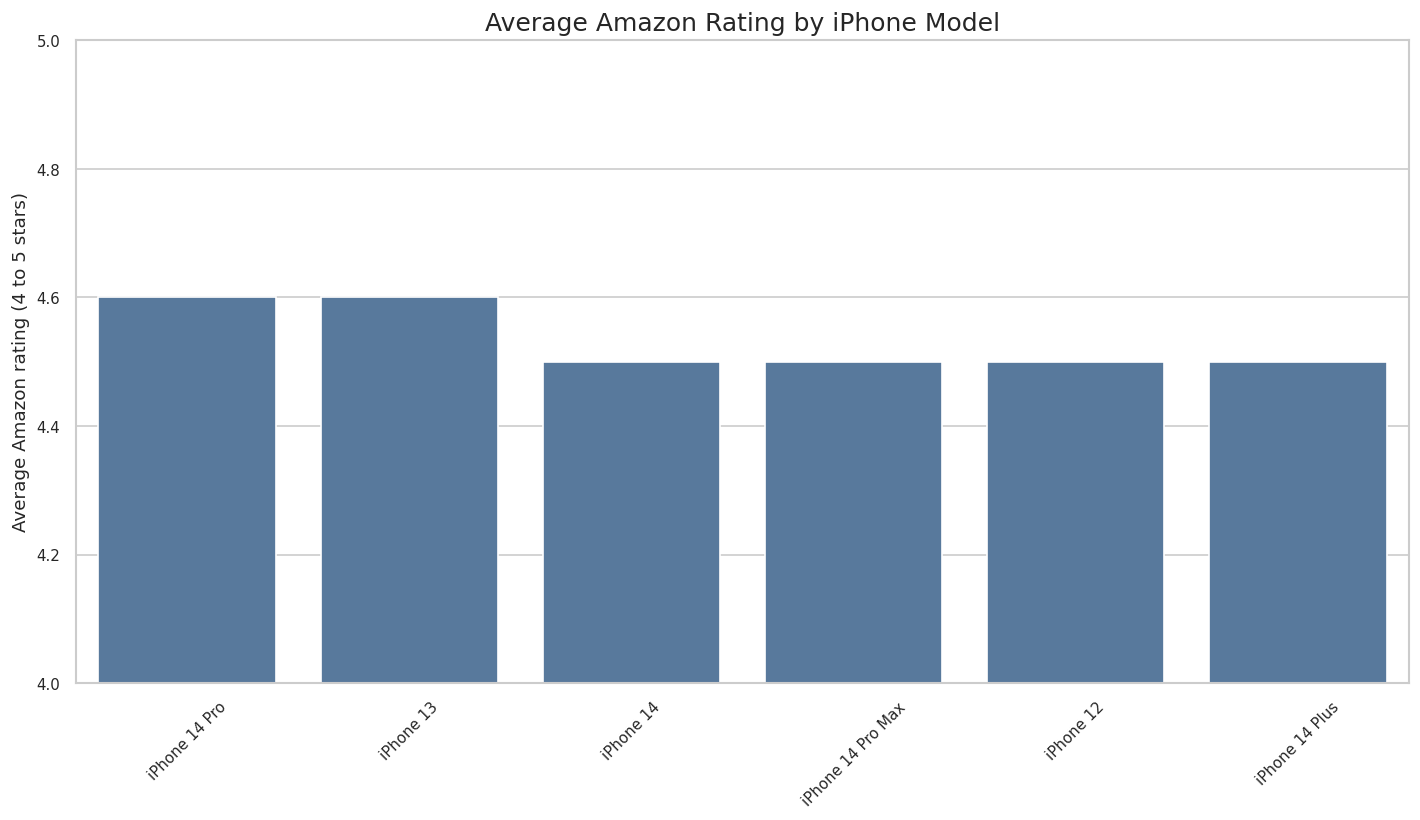

In [10]:
rating_order_simple = analysis_df.sort_values("average_rating", ascending=False)

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=rating_order_simple,
    x="model_name",
    y="average_rating",
    color="#4C78A8",
)
ax.set_title("Average Amazon Rating by iPhone Model")
ax.set_xlabel("")
ax.set_ylabel("Average Amazon rating (4 to 5 stars)")
ax.set_ylim(4, 5)
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## Chart 2: Average Rating vs Price

This chart adds price context to the story. It helps check whether the average-rating pattern is mainly about expensive or cheaper listings.

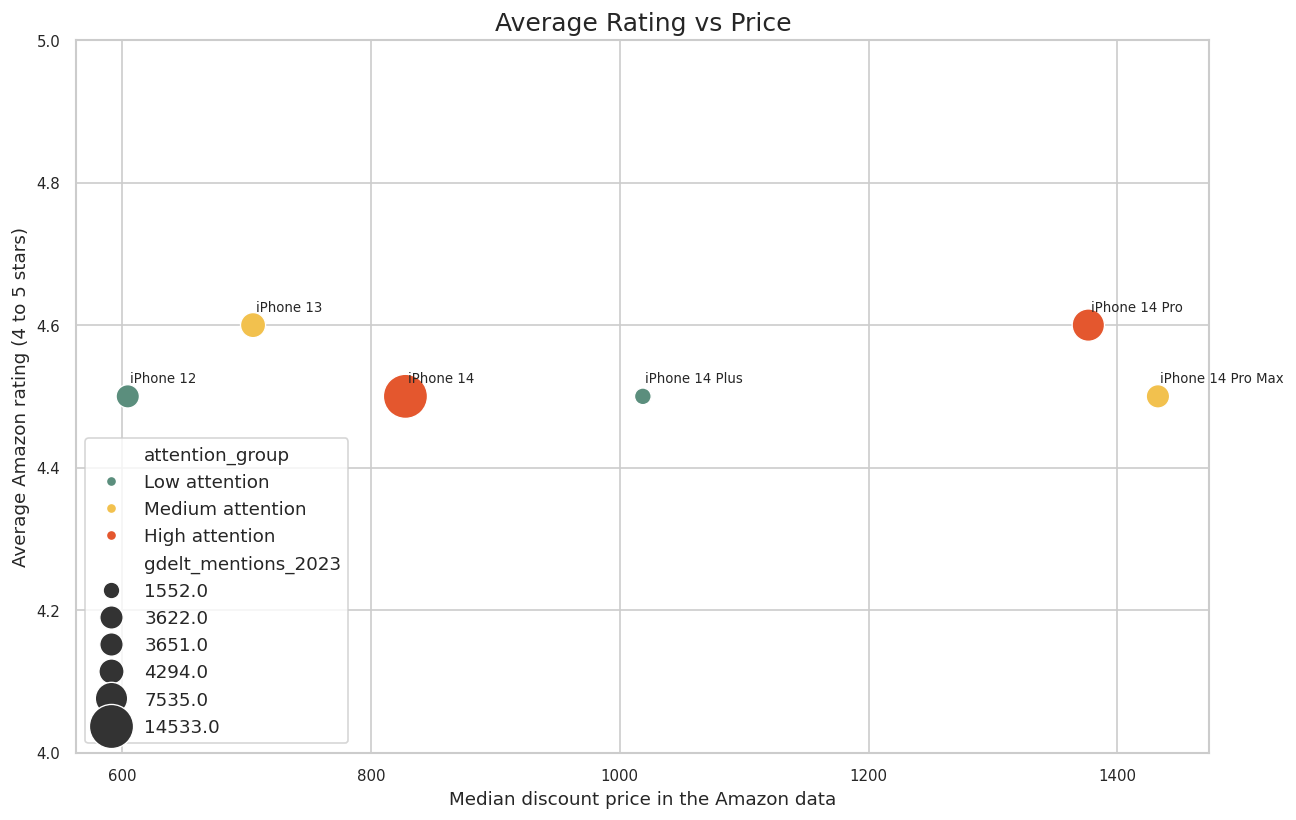

In [11]:
price_df = analysis_df.dropna(subset=["median_discount_price"]).copy()

plt.figure(figsize=(11, 7))
ax = sns.scatterplot(
    data=price_df,
    x="median_discount_price",
    y="average_rating",
    size="gdelt_mentions_2023",
    hue="attention_group",
    palette=["#5B8E7D", "#F2C14E", "#E4572E"],
    sizes=(100, 700),
    edgecolor="white",
    linewidth=0.8,
)
for _, row in price_df.iterrows():
    ax.text(row["median_discount_price"] + 2, row["average_rating"] + 0.02, row["model_name"], fontsize=8)
ax.set_title("Average Rating vs Price")
ax.set_xlabel("Median discount price in the Amazon data")
ax.set_ylabel("Average Amazon rating (4 to 5 stars)")
ax.set_ylim(4, 5)
plt.tight_layout()
plt.show()

## Chart 3: News Attention by iPhone Model


This chart shows which iPhone models were mentioned most often in 2023 news data. It sets up the "attention" side of the research question.

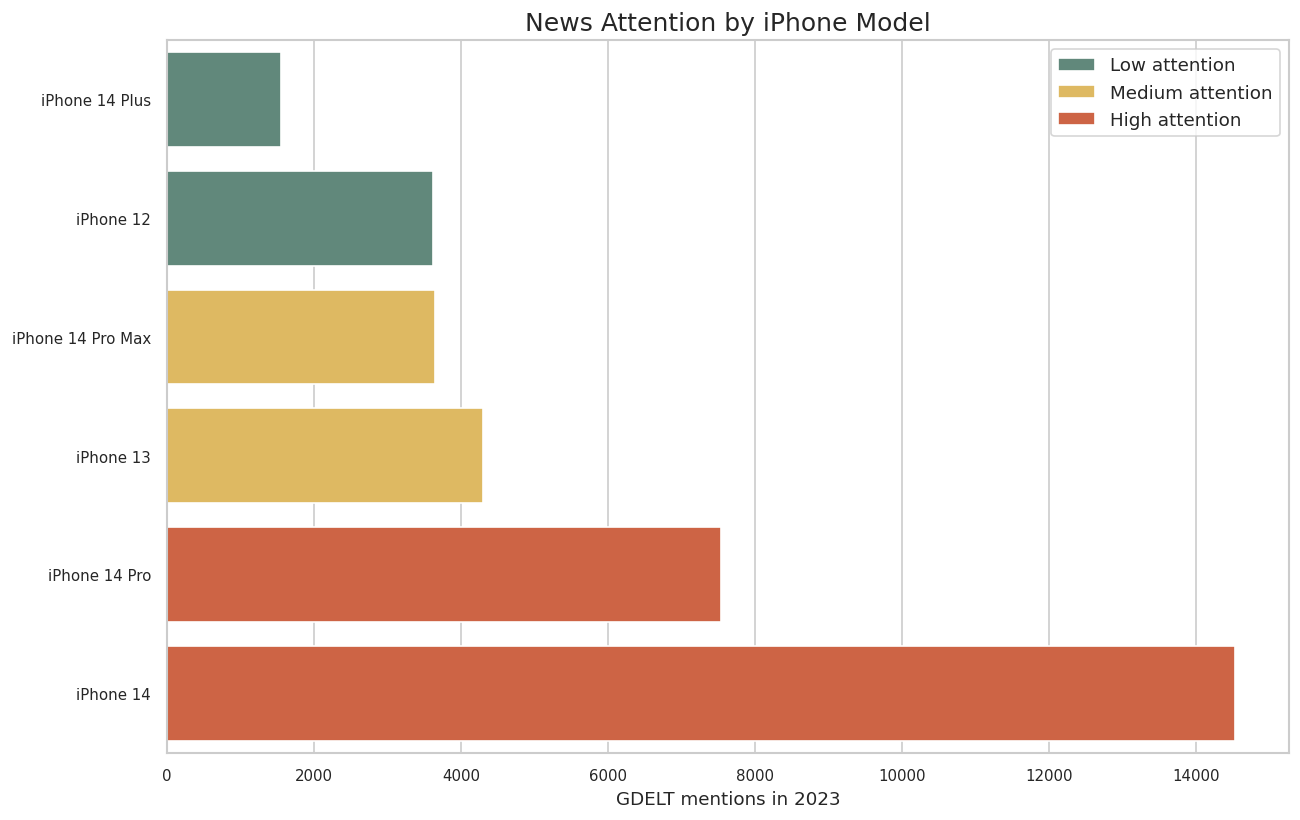

In [12]:
attention_order = analysis_df.sort_values("gdelt_mentions_2023", ascending=True)

plt.figure(figsize=(11, 7))
ax = sns.barplot(
    data=attention_order,
    x="gdelt_mentions_2023",
    y="model_name",
    hue="attention_group",
    dodge=False,
    palette=["#5B8E7D", "#F2C14E", "#E4572E"],
)
ax.set_title("News Attention by iPhone Model")
ax.set_xlabel("GDELT mentions in 2023")
ax.set_ylabel("")
ax.legend(title="")
plt.tight_layout()
plt.show()

## Chart 4: Average Rating and News Attention by iPhone Model


This chart compares the direct average Amazon rating for each model. It shows which models look strongest or weakest without applying an extra score calculation.

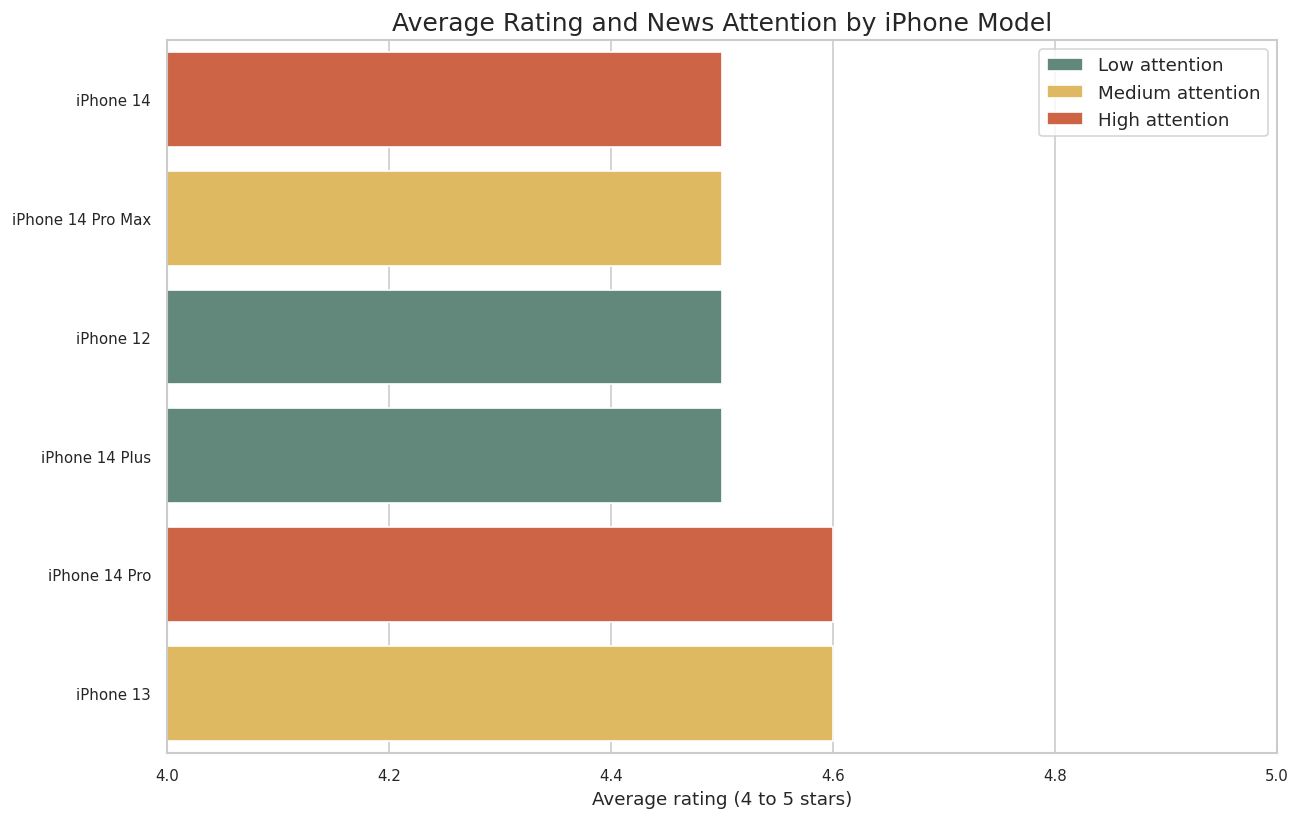

In [13]:
rating_order = analysis_df.sort_values("average_rating", ascending=True)

plt.figure(figsize=(11, 7))
ax = sns.barplot(
    data=rating_order,
    x="average_rating",
    y="model_name",
    hue="attention_group",
    dodge=False,
    palette=["#5B8E7D", "#F2C14E", "#E4572E"],
)
ax.set_title("Average Rating and News Attention by iPhone Model")
ax.set_xlabel("Average rating (4 to 5 stars)")
ax.set_ylabel("")
ax.set_xlim(4, 5)
ax.legend(title="")
plt.tight_layout()
plt.show()

## Results

The analysis shows that news attention and Amazon average ratings do not move together in a simple way. The most mentioned iPhone models are not automatically the models with the best Amazon ratings.

The main pattern is that newer and highly discussed models receive more news attention, but their average Amazon rating can still be weaker or more mixed. Older or less discussed models can look better because their customer ratings are more stable in the available listings.

For the research question, the simple answer is: more news attention does not mean better Amazon ratings. In this dataset, the story points slightly in the opposite direction: very visible iPhone models can have more mixed Amazon rating results.

This does not prove that news attention causes worse ratings. It only shows that attention and customer satisfaction are different signals. News attention mostly reflects public discussion, launches, and media interest, while the average Amazon rating reflects customer reviews in the available product listings.

In [14]:
spark.stop()